# Анализ Turbovec для семантического поиска

Пайплайн анализа:
1. Загрузка результатов бенчмарка (baseline и turbovec bw=2/bw=4; два прогона MS MARCO: 20k пассажей / 3086 запросов и 40k пассажей / 6066 запросов)
2. Объединение всех прогонов в общую таблицу
3. Для каждой конфигурации (прогон, bit_width) усреднить по-запросные метрики и провизуализировать (line chart):
- nDCG@5
- nDCG@10
- Recall@10
- MRR
4. Бутстрап доверительных интервалов для парной разницы средних
5. McNemar тест по бинарному исходу hit@k (recall@k > 0)
6. Forest plot (главный график со сводной информацией)

In [2]:
# Утилиты
from pathlib import Path
import re
import json
RESULTS_DIR = str(Path.cwd().parent / "results/semantic_search")
RESULTS_DIR = RESULTS_DIR.replace('\\', '/') + "/"

In [3]:
# Библиотеки для анализа данных
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.contingency_tables import mcnemar

## 1. Загрузка данных выборочно

In [4]:
tv_bw2_20k = pd.read_csv(RESULTS_DIR + 'turbovec_bw2_20260704_103102.csv')
bl_40k = pd.read_csv(RESULTS_DIR + 'baseline_20260705_105419.csv')

In [5]:
tv_bw2_20k.head()

,query_id,query_text,time_ms,ndcg@1,ndcg@5,ndcg@10,map@1,map@5,map@10,recall@1,recall@5,recall@10,precision@1,precision@5,precision@10,mrr
0,19699,what is rba,55.300474,0.0,0.5,0.5000,0.0,0.3333,0.3333,0.0,1.0,1.0,0.0,0.2,0.1,0.3333
1,19700,was ronald reagan a democrat,0.675917,1.0,1.0,1.0000,1.0,1.0000,1.0000,1.0,1.0,1.0,1.0,0.2,0.1,1.0000
2,19701,how long do you need for sydney and surroundin...,0.590324,1.0,1.0,1.0000,1.0,1.0000,1.0000,1.0,1.0,1.0,1.0,0.2,0.1,1.0000
3,19702,price to install tile in shower,0.580549,0.0,0.0,0.3333,0.0,0.0000,0.1429,0.0,0.0,1.0,0.0,0.0,0.1,0.1429
4,19703,why conversion observed in body,0.581503,1.0,1.0,1.0000,1.0,1.0000,1.0000,1.0,1.0,1.0,1.0,0.2,0.1,1.0000


In [6]:
tv_bw2_20k.describe()

,query_id,time_ms,ndcg@1,ndcg@5,ndcg@10,map@1,map@5,map@10,recall@1,recall@5,recall@10,precision@1,precision@5,precision@10,mrr
count,3086.000000,3086.000000,3086.000000,3086.000000,3086.000000,3086.000000,3086.000000,3086.000000,3086.000000,3086.000000,3086.000000,3086.000000,3086.000000,3086.000000,3086.000000
mean,30598.491899,0.685444,0.383020,0.632725,0.671727,0.383020,0.562328,0.573877,0.362517,0.855202,0.969061,0.383020,0.185483,0.105962,0.578155
std,20753.721781,0.998570,0.486202,0.336882,0.281084,0.486202,0.370863,0.348541,0.470343,0.342521,0.170760,0.486202,0.087148,0.036144,0.353420
min,19699.000000,0.550747,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20496.250000,0.582457,0.000000,0.430700,0.430700,0.000000,0.250000,0.250000,0.000000,1.000000,1.000000,0.000000,0.200000,0.100000,0.250000
50%,21292.500000,0.612736,0.000000,0.630900,0.630900,0.000000,0.500000,0.500000,0.000000,1.000000,1.000000,0.000000,0.200000,0.100000,0.500000
75%,22087.750000,0.691175,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.200000,0.100000,1.000000
max,102123.000000,55.300474,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.800000,0.600000,1.000000


## 2. Группировка таблиц

In [7]:
frames = []

for file in Path(RESULTS_DIR).glob("*.csv"):
    name = file.stem

    if name.startswith("baseline"):
        method = "baseline"
        bit_width = np.nan
    else:
        method = "turbovec"
        bit_width = int(re.search(r"bw(\d+)", name).group(1))

    run_id = name.split("_")[-2] + "_" + name.split("_")[-1]

    df = pd.read_csv(file)

    df["method"] = method
    df["bit_width"] = bit_width
    df["run_id"] = run_id

    frames.append(df)

all_df = pd.concat(frames, ignore_index=True)

all_df["variant"] = np.where(
    all_df.method=="baseline",
    "baseline",
    "turbovec_bw"+all_df.bit_width.astype("Int64").astype(str)
)

In [8]:
all_df.tail()

,query_id,query_text,time_ms,ndcg@1,ndcg@5,ndcg@10,map@1,map@5,map@10,recall@1,recall@5,recall@10,precision@1,precision@5,precision@10,mrr,method,bit_width,run_id,variant
27451,101845,how much is a nurses salary,2.092600,0.0,0.4307,0.4307,0.0,0.2500,0.2500,0.0,1.0,1.0,0.0,0.2,0.1,0.2500,turbovec,4.0,20260705_105419,turbovec_bw4
27452,101992,how are metalloids different from metals,2.091169,0.0,0.0000,0.0000,0.0,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,turbovec,4.0,20260705_105419,turbovec_bw4
27453,101996,gmo definition food good or bad,2.132416,0.0,0.0000,0.3562,0.0,0.0000,0.1667,0.0,0.0,1.0,0.0,0.0,0.1,0.1667,turbovec,4.0,20260705_105419,turbovec_bw4
27454,102091,thyroid gland produces calcitonin,2.108574,0.0,0.5000,0.5000,0.0,0.3333,0.3333,0.0,1.0,1.0,0.0,0.2,0.1,0.3333,turbovec,4.0,20260705_105419,turbovec_bw4
27455,102123,hydronic radiant floor heating cost per square...,2.108812,1.0,1.0000,1.0000,1.0,1.0000,1.0000,1.0,1.0,1.0,1.0,0.2,0.1,1.0000,turbovec,4.0,20260705_105419,turbovec_bw4


## 3. Вычисление метрик

In [9]:
summaries = {}
for f in sorted(Path(RESULTS_DIR).glob("summary_*.json")):
    s = json.loads(f.read_text())
    summaries[s["run_id"]] = s

MAIN_METRICS = ["ndcg@5", "ndcg@10", "recall@10", "mrr"]

def compute_metrics(sub):
    run_id = sub["run_id"].iloc[0]
    bit_width = sub["bit_width"].iloc[0]
    return (run_id, bit_width) + tuple(sub[m].mean() for m in MAIN_METRICS)

metrics_df = pd.DataFrame(
    [compute_metrics(sub) + (variant, summaries[run_id]["n_passages"])
     for (run_id, variant), sub in all_df.groupby(["run_id", "variant"])],
    columns=["run_id", "bit_width"] + MAIN_METRICS + ["variant", "n_passages"],
)
metrics_df.round(4)

,run_id,bit_width,ndcg@5,ndcg@10,recall@10,mrr,variant,n_passages
0,20260704_103102,NaN,0.6324,0.6730,0.9687,0.5799,baseline,20000
1,20260704_103102,2.0,0.6327,0.6717,0.9691,0.5782,turbovec_bw2,20000
2,20260704_103102,4.0,0.6327,0.6724,0.9691,0.5788,turbovec_bw4,20000
3,20260705_105419,NaN,0.6039,0.6476,0.9473,0.5546,baseline,40000
4,20260705_105419,2.0,0.5998,0.6438,0.9461,0.5504,turbovec_bw2,40000
5,20260705_105419,4.0,0.6044,0.6469,0.9471,0.5537,turbovec_bw4,40000


### График

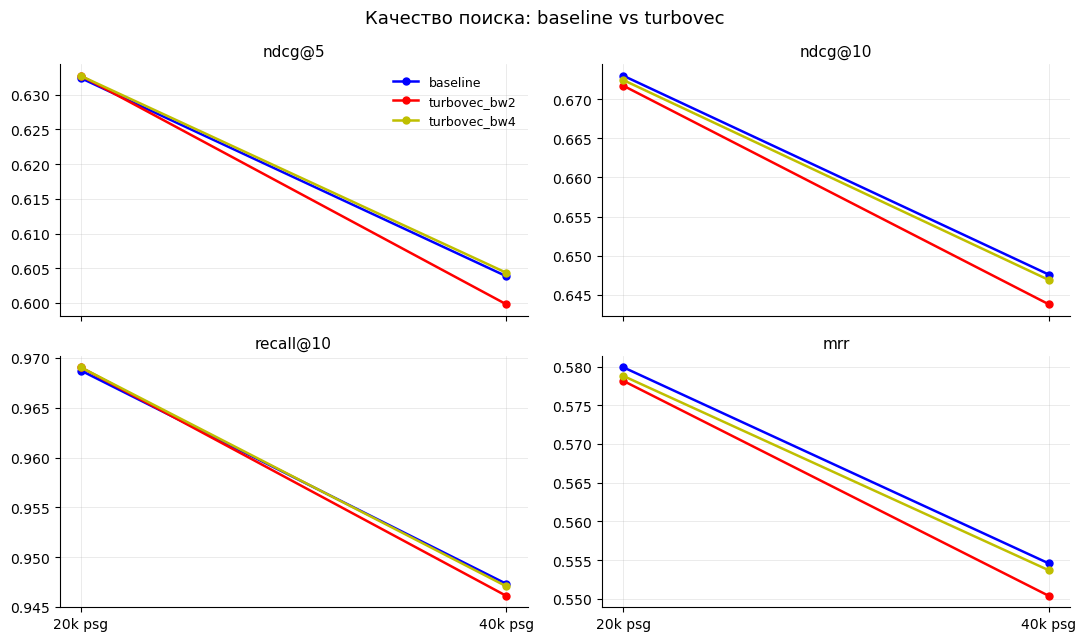

In [10]:
COLORS = {"baseline": "b", "turbovec_bw2": "r", "turbovec_bw4": "y"}

plot_df = metrics_df.sort_values("n_passages").copy()
plot_df["config"] = (plot_df["n_passages"] // 1000).astype(str) + "k psg"
order = plot_df["config"].drop_duplicates().tolist()

fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex=True)
for ax, metric in zip(axes.ravel(), MAIN_METRICS):
    for variant, color in COLORS.items():
        sub = plot_df[plot_df["variant"] == variant].set_index("config").reindex(order)
        ax.plot(order, sub[metric], marker="o", ms=5, lw=1.8, color=color, label=variant)
    ax.set_title(metric, fontsize=11)
    ax.grid(alpha=0.35, lw=0.5)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
axes[0, 0].legend(frameon=False, fontsize=9)
fig.suptitle("Качество поиска: baseline vs turbovec", fontsize=13)
fig.tight_layout()
plt.show()

Когда корпус больше, метрики немного проседают во всех конфигурациях

## 4. Бутстрап доверительных интервалов

In [11]:
def bootstrap_ci(sample, theta_func, alpha=0.05, B=1000, random_state=None, return_samples=False):
    if random_state is not None:
        np.random.seed(random_state)

    N = len(sample)
    theta_estim = theta_func(sample)

    theta_asterisk_array = []
    for _ in range(B):
        bootstrap_sample = np.random.choice(sample, replace=True, size=N)
        theta_asterisk = theta_func(bootstrap_sample)
        theta_asterisk_array.append(theta_asterisk)
    theta_asterisk_array = np.array(theta_asterisk_array)

    left_theta_asterisk, right_theta_asterisk = np.quantile(theta_asterisk_array, [alpha / 2, 1 - alpha / 2])
    left_bound = 2 * theta_estim - right_theta_asterisk
    right_bound = 2 * theta_estim - left_theta_asterisk

    if return_samples:
        return left_bound, right_bound, theta_estim, theta_asterisk_array
    return left_bound, right_bound


def compute_metric_diff_bootstrap(df, run_id, bit_width, metric='ndcg@10', alpha=0.05, B=1000, random_state=42):
    sub = df[df['run_id'] == run_id]
    baseline = sub[sub['variant'] == 'baseline'][['query_id', metric]]
    tv = sub[sub['variant'] == f'turbovec_bw{bit_width}'][['query_id', metric]]
    paired = baseline.merge(tv, on='query_id', suffixes=('_baseline', '_turbovec'))

    s_baseline = paired[metric + '_baseline'].values
    s_turbovec = paired[metric + '_turbovec'].values

    def theta_func(idx):
        idx = np.asarray(idx)
        return s_turbovec[idx].mean() - s_baseline[idx].mean()

    sample = np.arange(len(paired))
    ci_low, ci_high, theta_hat, theta_star = bootstrap_ci(
        sample, theta_func, alpha=alpha, B=B, random_state=random_state, return_samples=True
    )

    p_emp = min(2 * min((theta_star > 0).mean(), (theta_star < 0).mean()), 1.0)

    return dict(run_id=run_id, bit_width=bit_width, metric=metric, n=len(paired), n_boot=len(theta_star),
                observed_diff_turbovec_minus_baseline=theta_hat,
                ci95_low=ci_low, ci95_high=ci_high, p_value_empirical=p_emp)

In [12]:
boot_df = pd.DataFrame([
    compute_metric_diff_bootstrap(all_df, run_id, bw, metric=metric)
    for run_id in sorted(all_df["run_id"].unique())
    for bw in (2, 4)
    for metric in MAIN_METRICS
])
boot_df["n_passages"] = boot_df["run_id"].map(lambda r: summaries[r]["n_passages"])
boot_df.round(5)

,run_id,bit_width,metric,n,n_boot,observed_diff_turbovec_minus_baseline,ci95_low,ci95_high,p_value_empirical,n_passages
0,20260704_103102,2,ndcg@5,3086,1000,0.00034,-0.00357,0.00449,0.882,20000
1,20260704_103102,2,ndcg@10,3086,1000,-0.00128,-0.00506,0.00227,0.522,20000
2,20260704_103102,2,recall@10,3086,1000,0.00032,-0.00292,0.00341,0.796,20000
3,20260704_103102,2,mrr,3086,1000,-0.00175,-0.00678,0.00287,0.512,20000
4,20260704_103102,4,ndcg@5,3086,1000,0.00031,-0.00193,0.00260,0.800,20000
5,20260704_103102,4,ndcg@10,3086,1000,-0.00055,-0.00240,0.00129,0.588,20000
6,20260704_103102,4,recall@10,3086,1000,0.00032,-0.00130,0.00194,0.566,20000
7,20260704_103102,4,mrr,3086,1000,-0.00112,-0.00356,0.00134,0.394,20000
8,20260705_105419,2,ndcg@5,6066,1000,-0.00404,-0.00701,-0.00142,0.006,40000
9,20260705_105419,2,ndcg@10,6066,1000,-0.00380,-0.00639,-0.00138,0.000,40000


## 5. McNemar тест

По бинарному исходу hit@k: нашёлся ли хотя бы один релевантный пассаж в топ-k (recall@k > 0).

In [13]:
def mcnemar_test(df, run_id, bit_width, metric):
    sub = df[df['run_id'] == run_id]
    baseline = sub[sub['variant'] == 'baseline'][['query_id', metric]]
    tv = sub[sub['variant'] == f'turbovec_bw{bit_width}'][['query_id', metric]]
    paired = baseline.merge(tv, on='query_id', suffixes=('_baseline', '_turbovec'))

    bl_ok = paired[metric + '_baseline'] > 0
    tv_ok = paired[metric + '_turbovec'] > 0
    table = [[int((bl_ok & tv_ok).sum()), int((bl_ok & ~tv_ok).sum())],
             [int((~bl_ok & tv_ok).sum()), int((~bl_ok & ~tv_ok).sum())]]

    res = mcnemar(table, exact=False, correction=True)
    return dict(run_id=run_id, bit_width=bit_width, metric=metric,
                baseline_only_hit=table[0][1], turbovec_only_hit=table[1][0],
                statistic=res.statistic, p_value=res.pvalue)

mcnemar_df = pd.DataFrame([
    mcnemar_test(all_df, run_id, bw, metric)
    for run_id in sorted(all_df["run_id"].unique())
    for bw in (2, 4)
    for metric in ("recall@1", "recall@5", "recall@10")
])
mcnemar_df["n_passages"] = mcnemar_df["run_id"].map(lambda r: summaries[r]["n_passages"])
mcnemar_df.round(4)

,run_id,bit_width,metric,baseline_only_hit,turbovec_only_hit,statistic,p_value,n_passages
0,20260704_103102,2,recall@1,89,84,0.0925,0.7610,20000
1,20260704_103102,2,recall@5,36,47,1.2048,0.2724,20000
2,20260704_103102,2,recall@10,12,13,0.0000,1.0000,20000
3,20260704_103102,4,recall@1,32,26,0.4310,0.5115,20000
4,20260704_103102,4,recall@5,12,18,0.8333,0.3613,20000
5,20260704_103102,4,recall@10,3,4,0.0000,1.0000,20000
6,20260705_105419,2,recall@1,169,145,1.6847,0.1943,40000
7,20260705_105419,2,recall@5,95,78,1.4798,0.2238,40000
8,20260705_105419,2,recall@10,29,25,0.1667,0.6831,40000
9,20260705_105419,4,recall@1,60,46,1.5943,0.2067,40000


## 6. Forest plot

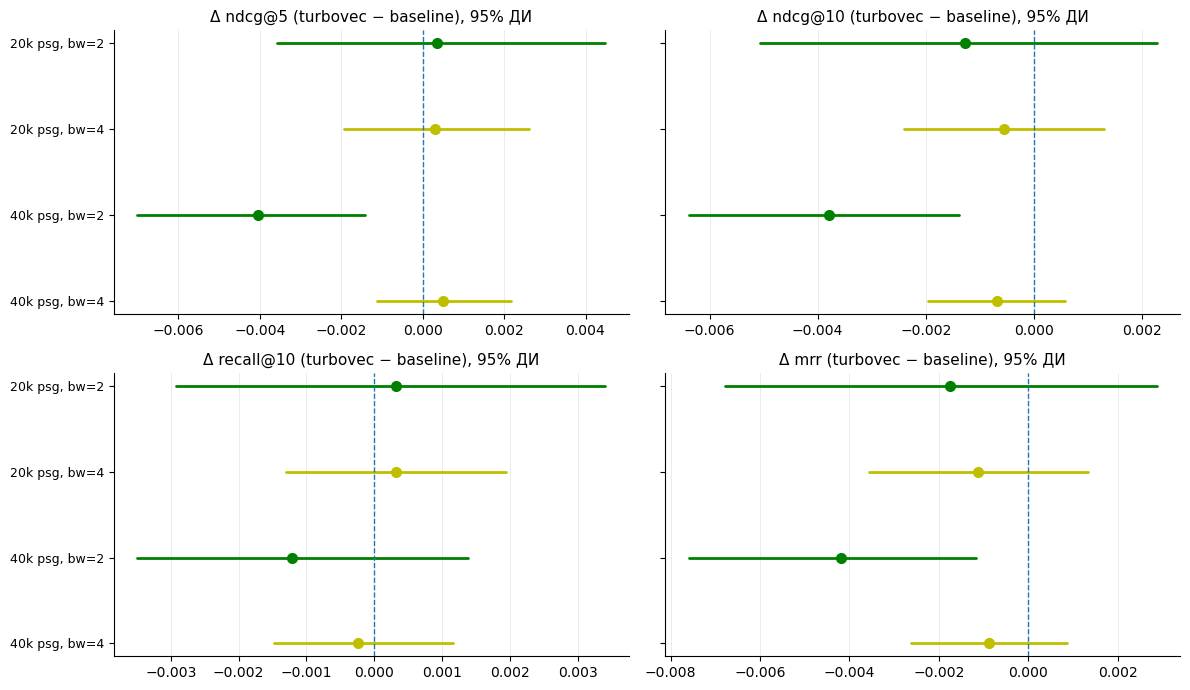

In [14]:
BW_COLORS = {2: "g", 4: "y"}

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=True)
for ax, metric in zip(axes.ravel(), MAIN_METRICS):
    sub = boot_df[boot_df["metric"] == metric].sort_values(
        ["n_passages", "bit_width"]).reset_index(drop=True)
    ypos = np.arange(len(sub))[::-1]
    for i, row in sub.iterrows():
        color = BW_COLORS[row["bit_width"]]
        ax.plot([row["ci95_low"], row["ci95_high"]], [ypos[i]] * 2,
                color=color, lw=2, solid_capstyle="round")
        ax.plot(row["observed_diff_turbovec_minus_baseline"], ypos[i], "o", ms=7, color=color)
    ax.axvline(0, lw=1, ls="--")
    labels = ((sub["n_passages"] // 1000).astype(str) + "k psg, bw=" + sub["bit_width"].astype(str))
    ax.set_yticks(ypos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_title(f"Δ {metric} (turbovec − baseline), 95% ДИ", fontsize=11)
    ax.grid(axis="x", alpha=0.35, lw=0.5)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.tight_layout()
plt.show()

## Вывод

Тurbovec подходит для семантического поиска, но с оговоркой по bw=2 на большом индексе.

- Прогон 20k пассажей: все различия статистически неотличимы от нуля (оба bit width, все метрики).
- Прогон 40k пассажей, bw=4: неотличим от baseline по всем метрикам.
- Прогон 40k пассажей, bw=2: небольшая, но статистически значимая просадка ранжирующих метрик: nDCG@5 −0.0040, nDCG@10 −0.0038, MRR −0.0042 (95% CI целиком ниже нуля).
- McNemar по hit@k не находит ухудшений нигде (0 из 12), а recall@10 такой же, как в baseline.

Итог: метрики либо не проседают, либо проседают на пренебрежимую величину при агрессивном сжатии на большем индексе. Лучше использовать bw=4